In [2]:
#Homework 6

In [1]:
# bayesian code
import numpy as np
import matplotlib.pyplot as plt
import math
#import math as comb
#import math as factorial

Bayes' theorem
$$
P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}
$$

Binomial probability distribution
$$
    P(h|\theta) = 
    \begin{pmatrix}
    n\\
    h
    \end{pmatrix} 
    \theta^h (1 - \theta)^{(n - h)}
$$
Where $h$ is the number of heads, $\theta$ is the probability of getting a head and $n$ is the total number of coin flips.

Beta function
$$
    P(\alpha,\beta,\theta) = \frac{\Gamma (\alpha + \beta)}{\Gamma (\alpha) \Gamma (\beta)} \theta^{(\alpha - 1)} (1-\theta)^{(\beta-1)}
$$
$\Gamma(x)$ is the gamma function

In [25]:
#Bayes' theorem
# P(H|E) = the posterior probability or the probability of H given E
# P(E|H) = the probability of observing E given H
# P(H) = the prior probability (before data is taken) of H being true
# P(E) = the probability only based on the data, which can be thought of as a normalization factor
# Where H is the hypothesis/model and E is the evidence/data. 

def bayesian_inference(prior_fn, likelihood_fn, data, num_points):

    # grid over parameter space
    theta_grid = np.linspace(0, 1, num_points)

    # compute prior P(H) and likelihood P(E|H)
    prior_vals = np.array([prior_fn(theta) for theta in theta_grid])
    likelihood_vals = np.array([likelihood_fn(data, theta) for theta in theta_grid])

    # unnormalized posterior
    posterior_unnormalized = prior_vals * likelihood_vals

    # normalize (numerical integration)
    area = np.trapz(posterior_unnormalized, theta_grid)
    posterior = posterior_unnormalized / area

    return theta_grid, posterior

# likelihood P(E|H) -> bionomial probability distribution
def likelihood(data, theta):
    #h, n = data
    n = len(data) # number of flipping
    h = sum(data) # number of head
    #coefficient
    fact = math.factorial(n) / ( math.factorial(h) * math.factorial(n - h) ) #or comb(n,h)
    return fact * theta**h * ((1-theta)**(n-h))

# prior P(H) -> beta function 
def beta_func(alpha,beta):
    def prior(theta):
        if theta < 0 or theta > 1:
            return 0.0
        return ( math.factorial(alpha + beta - 1) / ( math.factorial(alpha - 1) * math.factorial(beta - 1) ) ) * \
            theta**(alpha - 1) * ( (1 - theta)**(beta - 1) )
    return prior

#left = factorial(alpha + beta - 1) / ( factorial(alpha - 1) * factorial(beta - 1) )
#right = theta**(alpha - 1) * ( (1 - theta)**(beta - 1) )

# prior P(H) -> beta function 
def beta_like_prior(alpha, beta):
    def prior(theta):
        if theta < 0 or theta > 1:
            return 0.0
        return (theta ** (alpha - 1)) * ((1 - theta) ** (beta - 1))
    return prior

In [49]:
# using data
# 1 -> head, 0 -> tail
data = [1, 1, 1, 0, 1, 1, 1, 0]#np.loadtxt("HW06_data.txt", dtype = 'float', unpack = True, usecols = (0))
#[1, 1, 1, 0, 1, 1, 1, 0]
#theta_grid = np.linspace(0, 1, 1000)
alpha = 2
beta = 2
prior = beta_func(alpha,beta)

num_points = 1000

theta_grid, posterior = bayesian_inference(prior, likelihood, data, num_points)

print(f'number of flip = {len(data)}, number of head = {sum(data)}' )

number of flip = 8, number of head = 6


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13284\2126824182.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(posterior_unnormalized, theta_grid)


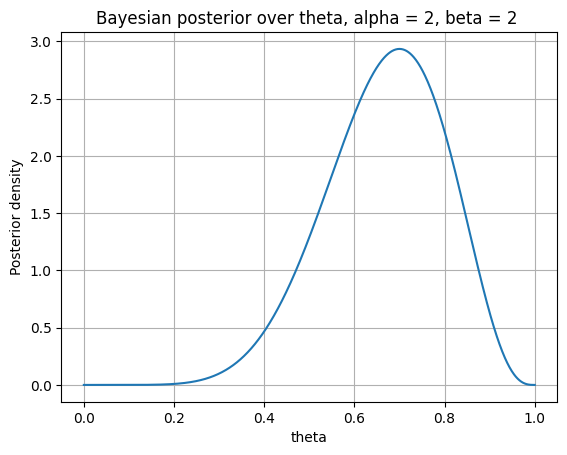

In [50]:
plt.plot(theta_grid, posterior)
plt.xlabel("theta")
plt.ylabel("Posterior density")
plt.title(f"Bayesian posterior over theta, alpha = {alpha}, beta = {beta} ")
plt.grid(True)